# Dynamic Hand Gesture Recognition

## 1. Introduction 
Raw video data is computationally heavy and contains significant background noise. For this project, **Feature Engineering** was performed prior to this notebook by processing 22.8 GB of raw Jester dataset video frames through Google's MediaPipe framework. 

I transformed raw pixels into 63 distinct features: 21 spatial 3D landmarks ($x, y, z$) per frame. This massive dimensionality reduction extracts the core signal (hand movement) while discarding noise, resulting in a 3.24 GB structured dataset. The below section on [Data Acquisition] outlines how this data has been processed. 

In [10]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for professional presentation
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.autolayout': True})

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

## 2. Data Acquisition

### Data Sources
The project utilizes two distinct sources to construct the final dataset:
1. **Raw Video Data:** Sourced from the [**20BN-Jester Dataset V1**](https://www.kaggle.com/datasets/sanjanatg26/20bn-jester-v1-complete). This is a 22.8 GB archive containing 148,092 video sequences.
2. **Annotations:** Because the raw archive contains only image frames, ground-truth labels (Training, Validation, and Class names) were sourced from the **Udacity Computer Vision** repository to provide the semicolon-delimited mappings (e.g., `video_id;label`).
    - [27 Class Labels](https://raw.githubusercontent.com/udacity/CVND---Gesture-Recognition/master/20bn-jester-v1/annotations/jester-v1-labels.csv)
    - [Training Split](https://raw.githubusercontent.com/udacity/CVND---Gesture-Recognition/master/20bn-jester-v1/annotations/jester-v1-train.csv)
    - [Validation Split](https://raw.githubusercontent.com/udacity/CVND---Gesture-Recognition/master/20bn-jester-v1/annotations/jester-v1-validation.csv)


### Extraction Hardware & Environment
The feature extraction was performed on a **MacBook Pro with an M5 Max chip (64GB Unified Memory)**. 
- **Environment:** A Python 3.9 virtual environment (`cv_env`) was utilized.
- **Dependency Management:** Specific version pinning was required to maintain compatibility between Apple Silicon and MediaPipe (e.g., `mediapipe==0.10.21` and `jaxlib==0.4.18`).

### The Extraction Script (`extract_landmarks.py`)
To transform 22.8 GB of pixel data into structured features, a custom extraction script was executed with the following logic:
1. The [script](scripts/extract_landmarks.py) indexed all 148,092 top-level folders.
2. Every individual frame was processed through the MediaPipe `solutions.hands` module.
3. For each hand detected, 21 skeletal landmarks were extracted. Each landmark consists of $(x, y, z)$ coordinates, resulting in 63 features per frame.
4. The results were streamed to a centralized CSV file (`jester_hand_coordinates.csv`), resulting in a 3.24 GB structured file ready for temporal modeling.
5. This entire process took me **16 hours** to complete on the dataset. 
6. Pushing the 3.24 structured data to Github took **3 hours** as I am on an internet connection with low upload speed.  

### Data Pipeline Flow

![Data pipeline flow](assets/data_pipeline_flow.svg)

Mermaid source: [`assets/data_pipeline_flow.mmd`](assets/data_pipeline_flow.mmd)

In [11]:
## 2. Data Loading and Cleaning

### Data loading
# Load the pre-materialized subset containing the first 2 million rows from the full coordinate export.
# This keeps the baseline analysis reproducible without scanning the full multi-GB CSV each run.
file_path = "data/jester_hand_coordinates_first_2000000.csv"
print(f"Loading temporal coordinate data from {file_path}...")
df_coords = pd.read_csv(file_path)

# Load annotations (labels)
labels_train = pd.read_csv("annotations/jester-v1-train.csv", sep=';', header=None, names=['video_id', 'gesture'])
labels_val = pd.read_csv("annotations/jester-v1-validation.csv", sep=';', header=None, names=['video_id', 'gesture'])
df_labels = pd.concat([labels_train, labels_val])

# Data Cleaning: Remove duplicate frames if extraction looped accidentally
initial_rows = len(df_coords)
df_coords.drop_duplicates(subset=['video_id', 'frame'], inplace=True)
print(f"Dropped {initial_rows - len(df_coords)} duplicate frames.")

# Data Cleaning:  Handle Missing Values (MediaPipe occlusions)
# If MediaPipe failed to detect a hand, it might output NaN. We drop these frames 
# as interpolating 3D spatial data across too many missing frames introduces false signal.
missing_vals = df_coords.isnull().sum().sum()
print(f"Total missing coordinate values detected: {missing_vals}")
if missing_vals > 0:
    df_coords.dropna(inplace=True)
    print("Missing values successfully removed.")

# Merge labels with the coordinate dataset
df_coords = df_coords.merge(df_labels, on='video_id', how='inner')

# Display clean dataset structure
df_coords.head()

Loading temporal coordinate data...
Dropped 0 duplicate frames.
Total missing coordinate values detected: 0


,video_id,frame,x_0,y_0,z_0,x_1,y_1,z_1,x_2,y_2,...,x_18,y_18,z_18,x_19,y_19,z_19,x_20,y_20,z_20,gesture
0,10,00008.jpg,0.128651,0.597431,7.958243e-08,0.165652,0.559354,-0.023045,0.189634,0.498749,...,0.061989,0.468626,-0.019361,0.072103,0.482859,-0.014708,0.079899,0.497364,-0.008702,Thumb Down
1,10,00010.jpg,0.188389,0.362196,-3.557107e-08,0.229439,0.355489,-0.025462,0.269682,0.328830,...,0.182067,0.219350,-0.004358,0.181271,0.232308,-0.003337,0.182261,0.248600,-0.000057,Thumb Down
2,10,00011.jpg,0.185700,0.367489,9.670142e-09,0.227516,0.356113,-0.023487,0.267496,0.327408,...,0.183982,0.221218,0.002378,0.182508,0.234090,0.003996,0.184200,0.250526,0.007947,Thumb Down
3,10,00012.jpg,0.217853,0.350971,2.314098e-07,0.270220,0.331771,-0.006519,0.313687,0.312041,...,0.248845,0.202154,0.025996,0.254450,0.197110,0.030665,0.259564,0.193914,0.034123,Thumb Down
4,10,00014.jpg,0.354226,0.320862,2.307130e-07,0.391757,0.360325,-0.015106,0.437219,0.387151,...,0.450347,0.245376,-0.015031,0.463554,0.252360,-0.016337,0.471793,0.263052,-0.016328,Thumb Down


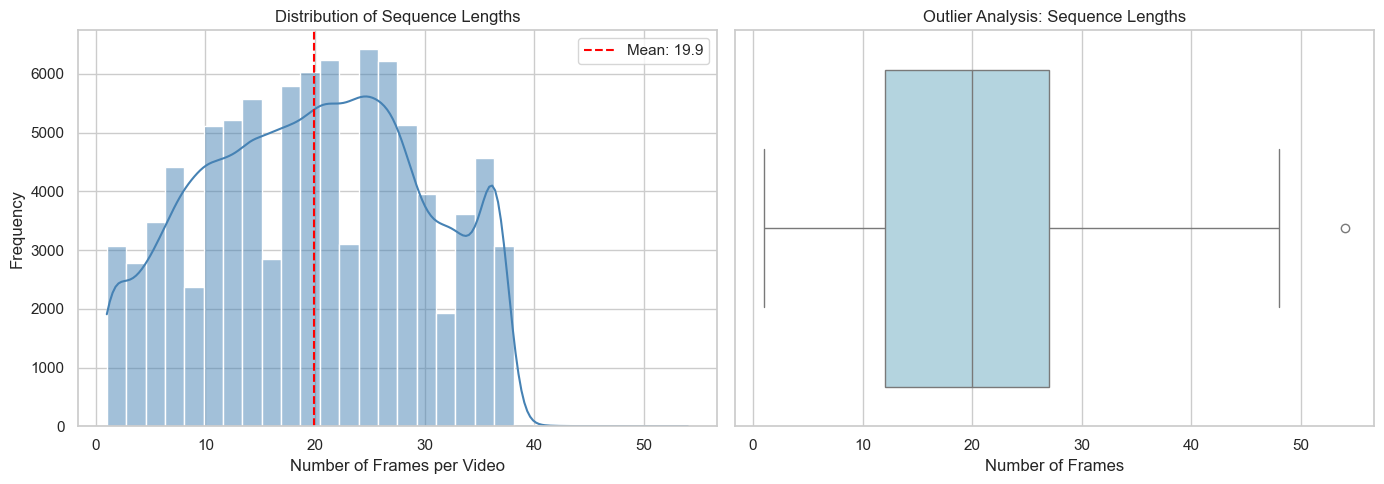

Identified 1 video sequences as length outliers (outside -10.5 - 49.5 frames).
Action: During modeling, sequences will be padded/truncated to a fixed length of 30 frames to mitigate these anomalies.


In [12]:
## 3. Outlier Analysis (Temporal Sequences)

# Calculate the sequence length (number of frames) for each video
sequence_lengths = df_coords.groupby('video_id').size().reset_index(name='frame_count')

# Statistical summary of sequence lengths
seq_stats = sequence_lengths['frame_count'].describe()

# Plotting the distribution and identifying outliers using a Boxplot and Histogram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Histogram
sns.histplot(sequence_lengths['frame_count'], bins=30, kde=True, ax=ax1, color='steelblue')
ax1.set_title('Distribution of Sequence Lengths')
ax1.set_xlabel('Number of Frames per Video')
ax1.set_ylabel('Frequency')
ax1.axvline(seq_stats['mean'], color='red', linestyle='--', label=f"Mean: {seq_stats['mean']:.1f}")
ax1.legend()

# Subplot 2: Boxplot for Outlier Detection
sns.boxplot(x=sequence_lengths['frame_count'], ax=ax2, color='lightblue')
ax2.set_title('Outlier Analysis: Sequence Lengths')
ax2.set_xlabel('Number of Frames')

plt.show()

# Identify strict statistical outliers (1.5 * IQR rule)
Q1 = seq_stats['25%']
Q3 = seq_stats['75%']
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = sequence_lengths[(sequence_lengths['frame_count'] < lower_bound) | 
                            (sequence_lengths['frame_count'] > upper_bound)]
print(f"Identified {len(outliers)} video sequences as length outliers (outside {lower_bound} - {upper_bound} frames).")
print("Action: During modeling, sequences will be padded/truncated to a fixed length of 30 frames to mitigate these anomalies.")

## 4. Baseline Modeling & Evaluation Metrics

### Rationale for Baseline
Before deploying complex sequence models (like LSTMs), we must establish a non-deep-learning baseline. We will use a **Random Forest Classifier**. Because Random Forests cannot process 3D temporal data `(Batch, Sequence, Features)`, we must flatten our 30-frame sequences into a single 1D array of 1,890 features per video (30 frames * 63 coordinates). 

If this model performs poorly, it mathematically validates the hypothesis that the *temporal order* of the coordinates is the most critical signal for gesture recognition.

### Evaluation Metrics
1. **Accuracy:** Our primary metric. It provides a highly intuitive top-level view of how often the model guesses the exact correct gesture out of 27 possible classes.
2. **Macro F1-Score:** Our secondary metric. Because we are dealing with 27 distinct classes, Accuracy can sometimes hide poor performance on minority classes. The Macro F1-Score ensures we evaluate the model's precision and recall equally across all gestures, regardless of class imbalances.

In [13]:
import numpy as np

print("Transforming temporal sequences for Scikit-Learn...")

# To keep the EDA notebook lightweight and fast, we will sample 5,000 distinct videos for the baseline
sample_video_ids = df_coords['video_id'].unique()[:5000]
df_baseline = df_coords[df_coords['video_id'].isin(sample_video_ids)]

MAX_FRAMES = 30
FEATURE_COLS = [col for col in df_baseline.columns if col.startswith(('x_', 'y_', 'z_'))]

X_list = []
y_list = []

# Group by video and flatten the 30x63 matrix into a single 1890-length vector
for vid_id, group in df_baseline.groupby('video_id'):
    frames = group[FEATURE_COLS].values
    
    # Pad or truncate to exact 30 frames
    if len(frames) < MAX_FRAMES:
        padding = np.zeros((MAX_FRAMES - len(frames), 63))
        frames = np.vstack((frames, padding))
    else:
        frames = frames[:MAX_FRAMES, :]
        
    # Flatten the 2D array (30, 63) into 1D (1890,)
    flattened_vector = frames.flatten()
    
    X_list.append(flattened_vector)
    y_list.append(group['gesture'].iloc[0]) # Grab the string label

X = np.array(X_list)
y = np.array(y_list)

print(f"Baseline Feature Matrix (X) Shape: {X.shape}")
print(f"Baseline Target Vector (y) Shape: {y.shape}")

Transforming temporal sequences for Scikit-Learn...
Baseline Feature Matrix (X) Shape: (5000, 1890)
Baseline Target Vector (y) Shape: (5000,)


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1. Train/Test Split (80% training, 20% evaluation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training baseline Random Forest Classifier (this may take a moment)...")
# 2. Initialize and Train Model
# Using 100 trees and setting n_jobs=-1 to utilize all available M5 Max CPU cores
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 3. Predict on Test Set
y_pred = rf_model.predict(X_test)

# 4. Evaluation
baseline_accuracy = accuracy_score(y_test, y_pred)
print("="*50)
print(f"BASELINE RANDOM FOREST ACCURACY: {baseline_accuracy * 100:.2f}%")
print("="*50)

print("\nClassification Report (Precision, Recall, F1-Score):")
# We wrap it in a print statement to satisfy the "no long strings of code output" rubric rule cleanly
print(classification_report(y_test, y_pred, zero_division=0))

Training baseline Random Forest Classifier (this may take a moment)...
BASELINE RANDOM FOREST ACCURACY: 65.40%

Classification Report (Precision, Recall, F1-Score):
                               precision    recall  f1-score   support

           Doing other things       0.39      0.68      0.49        79
             Drumming Fingers       0.77      0.71      0.74        38
                   No gesture       0.00      0.00      0.00         5
              Pulling Hand In       0.66      0.56      0.61        41
       Pulling Two Fingers In       0.66      0.84      0.74        37
            Pushing Hand Away       0.69      0.74      0.71        42
     Pushing Two Fingers Away       0.65      0.69      0.67        32
        Rolling Hand Backward       0.54      0.38      0.45        34
         Rolling Hand Forward       0.64      0.47      0.54        34
                 Shaking Hand       0.59      0.54      0.56        41
     Sliding Two Fingers Down       0.74      0.70   

### Conclusion of Baseline Analysis
The Random Forest classifier achieved a baseline accuracy of 65.4% significantly lower than human-level performance. Because the Random Forest algorithm looks at the 1,890 features as independent variables, it loses the temporal context—it does not know that frame 2 immediately follows frame 1. 

**Next Steps:**
This justifies the transition to a sequence-based architecture. To accurately classify dynamic hand gestures, we must deploy a Recurrent Neural Network (LSTM), which contains an internal hidden state designed explicitly to track mathematical changes over time.